<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Module_4_Data_Visualization_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Data Visualization Techniques

## Syllabus

This notebook covers:

- Data visualization techniques
- Importance of data visualization
- Choosing appropriate visualization methods
- Visualizing data insights and findings
- Matplotlib: line plots, bar charts, scatter plots, histograms, and subplots
- Seaborn: pair plots, violin plots, heatmaps, and regression plots
- Pandas quick data visualization
- Integrating visualization tools into data science workflows

## Learning Goals

By the end of this notebook, you should be able to:

1. Explain the purpose and importance of data visualization.
2. Select an appropriate chart for a particular data question.
3. Create common visualizations using Matplotlib.
4. Create statistical visualizations using Seaborn.
5. Visualize Pandas DataFrames directly.
6. Interpret charts and extract useful findings.
7. Avoid common visualization mistakes.
8. Answer theory, practical, viva, and exam questions.

## 1. What is Data Visualization?

Data visualization is the graphical representation of data using charts, plots, graphs, and other visual elements.

Instead of examining hundreds of numerical values individually, visualization helps us identify:

- Trends
- Patterns
- Relationships
- Distributions
- Outliers
- Comparisons
- Changes over time

### Exam Definition

**Data visualization is the process of representing data graphically to communicate patterns, relationships, trends, and insights effectively.**

### Why is visualization important?

A good visualization can make complex data easier to understand and can help analysts communicate findings to technical and non-technical audiences.

## 2. Choosing the Right Visualization

The correct chart depends on the question being asked.

| Analytical Question | Suitable Visualization |
|---|---|
| How does a value change over time? | Line plot |
| Compare categories | Bar chart |
| Relationship between two numerical variables | Scatter plot |
| Distribution of one numerical variable | Histogram |
| Distribution across categories | Violin plot / Box plot |
| Relationship among many numerical variables | Pair plot |
| Correlation among variables | Heatmap |
| Relationship with fitted trend | Regression plot |
| Multiple charts in one figure | Subplots |

### Important Principle

Do not choose a chart simply because it looks attractive. Choose it because it communicates the required information clearly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

np.random.seed(42)

dates = pd.date_range("2026-01-01", periods=30, freq="D")

df = pd.DataFrame({
    "Date": dates,
    "Sales": np.random.randint(100, 300, 30),
    "Customers": np.random.randint(20, 80, 30),
    "Advertising": np.random.randint(10, 60, 30),
    "Department": np.random.choice(["CSE", "ECE", "ME", "CE"], 30),
    "Gender": np.random.choice(["Male", "Female"], 30),
    "Marks": np.random.randint(35, 96, 30),
    "Attendance": np.random.randint(55, 100, 30)
})

df.head()

,Date,Sales,Customers,Advertising,Department,Gender,Marks,Attendance
0,2026-01-01,202,63,18,CE,Female,58,93
1,2026-01-02,279,44,35,ME,Male,71,86
2,2026-01-03,192,68,11,CE,Female,69,58
3,2026-01-04,114,46,29,ECE,Female,78,84
4,2026-01-05,206,78,37,ME,Female,74,91


## 3. Matplotlib

Matplotlib is one of the most widely used Python libraries for creating static visualizations.

Basic workflow:

1. Prepare data.
2. Create a figure.
3. Create the plot.
4. Add title and labels.
5. Add legend when required.
6. Display the plot.

Common functions:

- `plt.plot()`
- `plt.bar()`
- `plt.scatter()`
- `plt.hist()`
- `plt.subplots()`
- `plt.xlabel()`
- `plt.ylabel()`
- `plt.title()`
- `plt.legend()`
- `plt.grid()`
- `plt.show()`

## 4. Line Plot

A line plot is useful for showing trends or changes over an ordered variable, especially time.

### Syntax

```python
plt.plot(x, y)
```

Use a line plot when the order of observations matters.

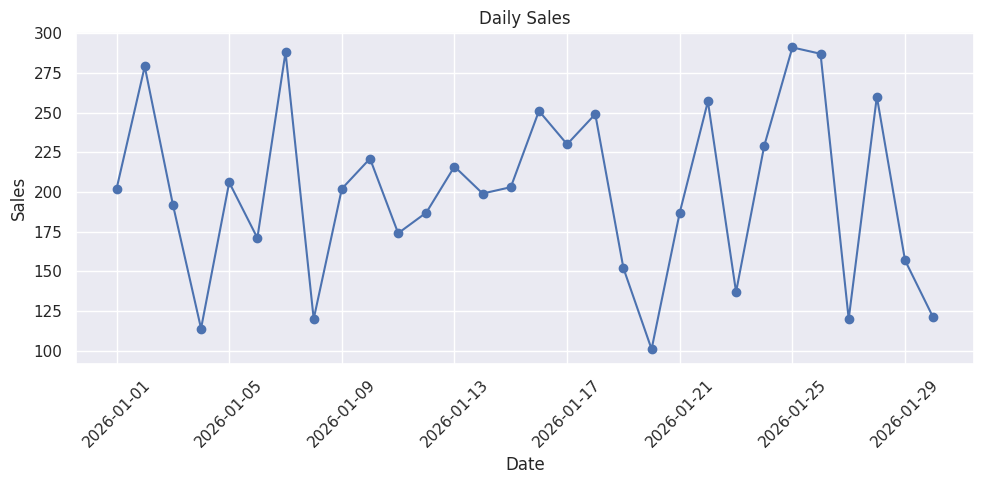

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Sales"], marker="o")
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The line connects observations in sequence, making it easier to see increases, decreases, peaks, and periods of relatively stable values.

### Common mistake

Do not use a line chart for unrelated categories merely because a line chart is easy to create. Lines imply an ordered relationship.

## 5. Bar Chart

Bar charts are useful for comparing values across discrete categories.

Examples:

- Sales by department
- Number of students by course
- Revenue by product

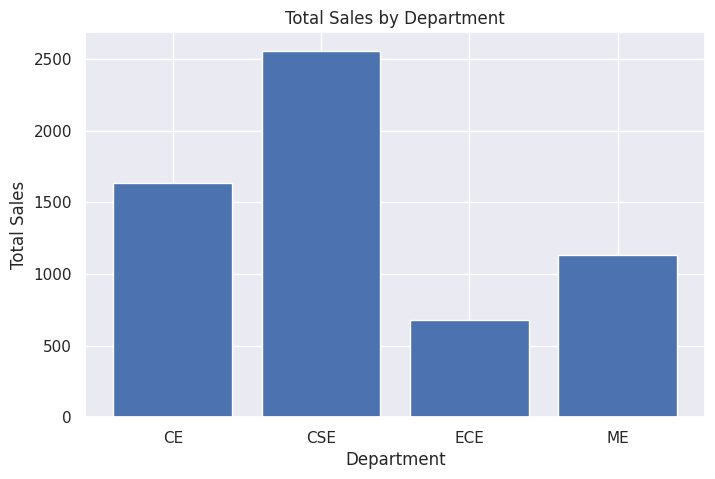

In [3]:
department_sales = df.groupby("Department")["Sales"].sum()

plt.figure(figsize=(8, 5))
plt.bar(department_sales.index, department_sales.values)
plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.show()

### Horizontal Bar Chart

A horizontal bar chart is useful when category names are long.

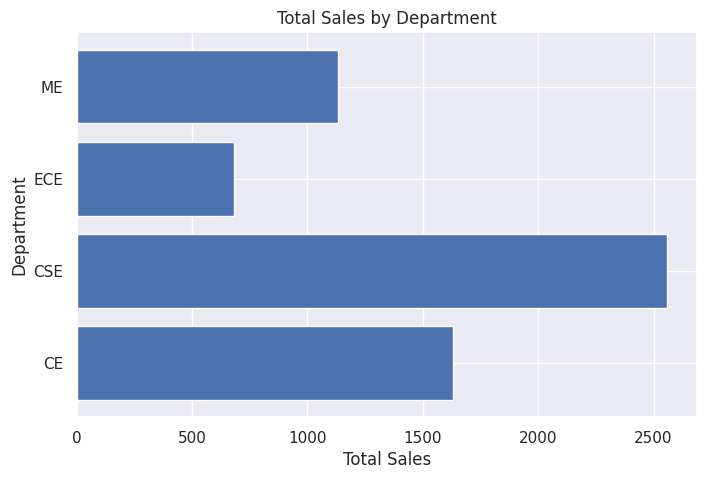

In [4]:
plt.figure(figsize=(8, 5))
plt.barh(department_sales.index, department_sales.values)
plt.title("Total Sales by Department")
plt.xlabel("Total Sales")
plt.ylabel("Department")
plt.show()

## 6. Scatter Plot

A scatter plot shows the relationship between two numerical variables.

It can help identify:

- Positive relationships
- Negative relationships
- Weak relationships
- Clusters
- Outliers

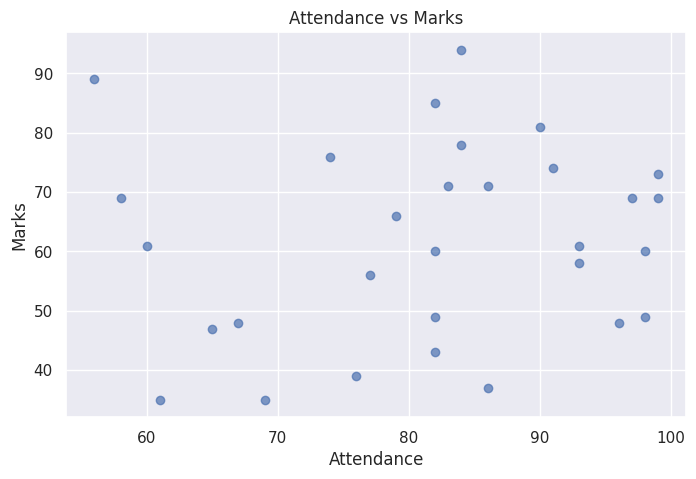

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Attendance"], df["Marks"], alpha=0.7)
plt.title("Attendance vs Marks")
plt.xlabel("Attendance")
plt.ylabel("Marks")
plt.show()

### Interpretation

Look for the overall direction and concentration of points.

A scatter plot can suggest a relationship, but a visible association alone does not establish causation.

## 7. Histogram

A histogram shows the distribution of a numerical variable by dividing values into bins.

Useful for understanding:

- Center
- Spread
- Skewness
- Possible outliers
- Concentration of observations

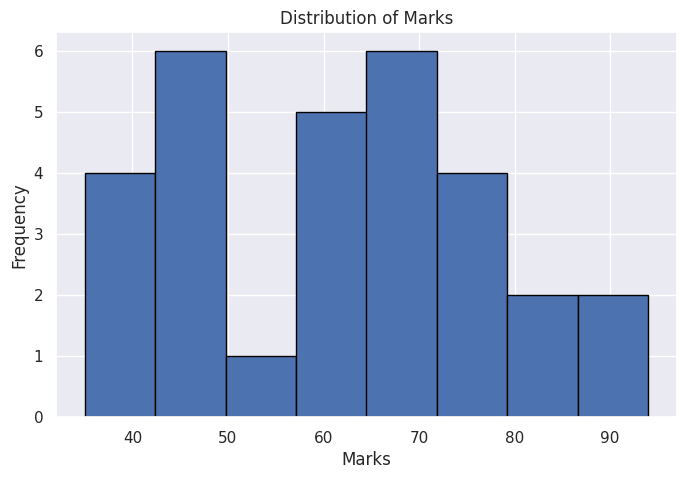

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["Marks"], bins=8, edgecolor="black")
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

### Important parameter: bins

`bins` controls how the numerical range is divided.

Too few bins may hide important structure. Too many bins may make the distribution noisy.

There is no single universally correct number of bins; it depends on the dataset and analytical purpose.

## 8. Subplots

Subplots allow multiple charts to be displayed within one figure.

They are useful when related visualizations need to be compared.

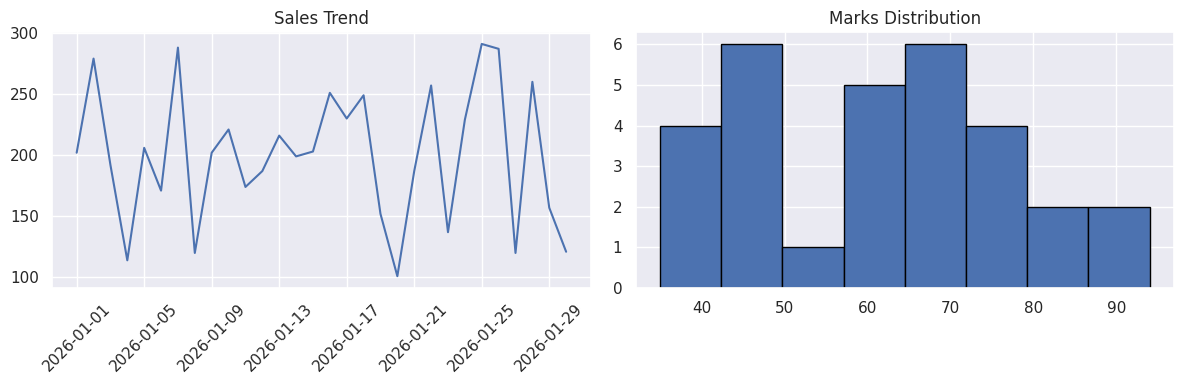

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["Date"], df["Sales"])
axes[0].set_title("Sales Trend")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(df["Marks"], bins=8, edgecolor="black")
axes[1].set_title("Marks Distribution")

plt.tight_layout()
plt.show()

## 9. Seaborn

Seaborn is a statistical visualization library built on top of Matplotlib.

It provides convenient functions for:

- Statistical relationships
- Distributions
- Categorical data
- Correlation visualization
- Multi-variable exploration

Common Seaborn functions:

- `sns.scatterplot()`
- `sns.lineplot()`
- `sns.barplot()`
- `sns.histplot()`
- `sns.boxplot()`
- `sns.violinplot()`
- `sns.heatmap()`
- `sns.pairplot()`
- `sns.regplot()`

## 10. Seaborn Pair Plot

A pair plot compares multiple numerical variables against each other.

It is useful for exploratory data analysis when you want an overview of relationships and distributions.

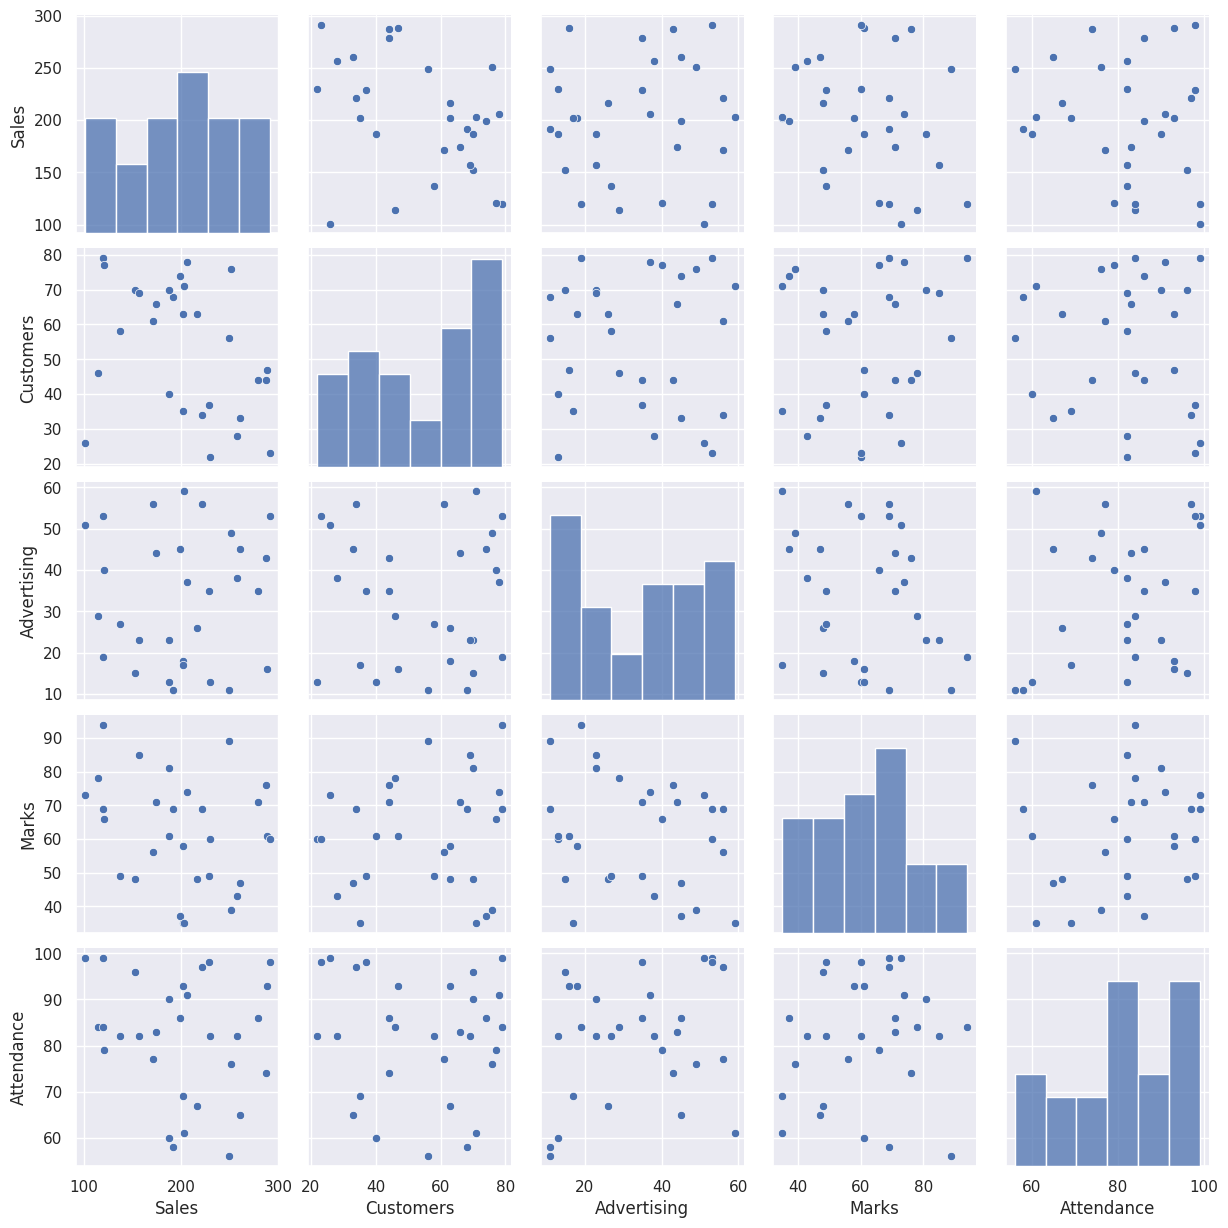

In [8]:
sns.pairplot(
    df[["Sales", "Customers", "Advertising", "Marks", "Attendance"]]
)
plt.show()

### How to read a pair plot

- Off-diagonal plots show relationships between pairs of variables.
- Diagonal plots show distributions of individual variables.

Pair plots are useful for initial exploration but can become difficult to read with many variables.

## 11. Violin Plot

A violin plot shows the distribution of a numerical variable across categories.

It combines information about distribution shape with a central summary.

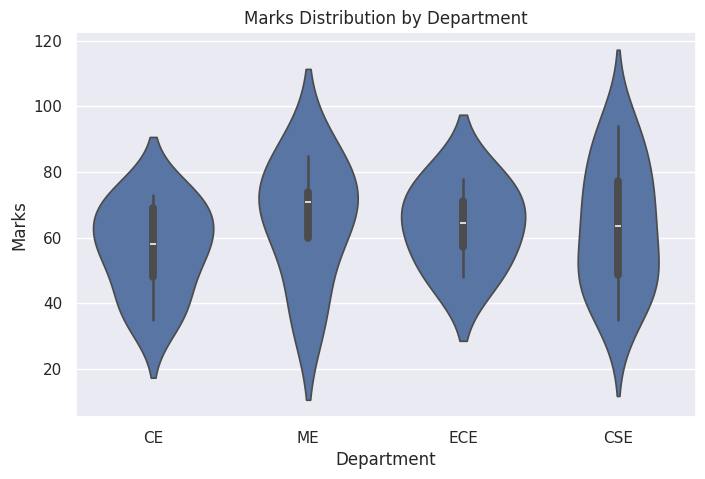

In [9]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Department", y="Marks")
plt.title("Marks Distribution by Department")
plt.show()

### When to use a violin plot

Use it when the distribution within each category matters, not just the average.

For simple comparisons, a bar plot or box plot may sometimes be easier to interpret.

## 12. Heatmap

A heatmap represents numerical values using a matrix of visual intensity.

It is commonly used to visualize correlation matrices.

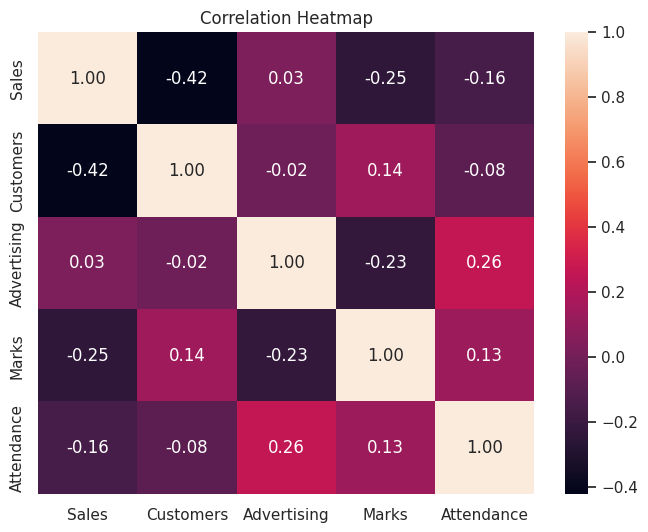

In [10]:
numeric_cols = ["Sales", "Customers", "Advertising", "Marks", "Attendance"]
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Correlation

Correlation measures the strength and direction of a linear relationship between two numerical variables.

Values are generally between -1 and +1.

- Close to +1: strong positive linear relationship
- Close to -1: strong negative linear relationship
- Close to 0: weak or no linear relationship

Exam Tip: Correlation does not by itself prove causation.

## 13. Regression Plot

A regression plot combines a scatter plot with an estimated linear trend.

It is useful for visually examining a possible linear relationship.

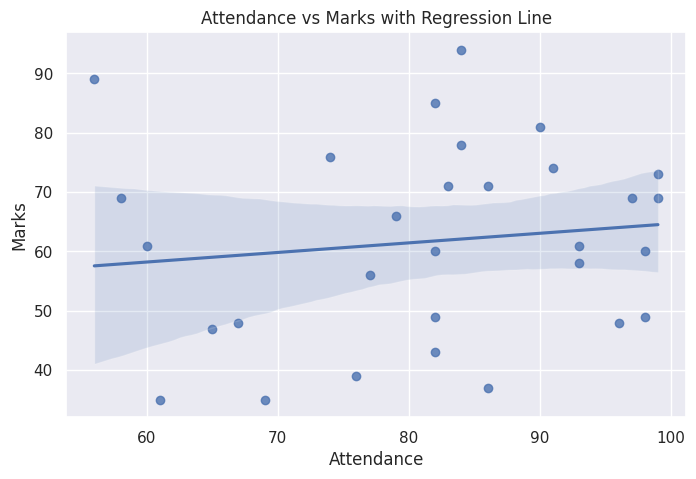

In [11]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Attendance", y="Marks")
plt.title("Attendance vs Marks with Regression Line")
plt.show()

## 14. Pandas Quick Visualization

Pandas provides simple plotting methods that internally use Matplotlib.

Examples:

```python
df["Sales"].plot()
df["Marks"].plot(kind="hist")
df.groupby("Department")["Sales"].sum().plot(kind="bar")
```

This is convenient for quick exploratory analysis.

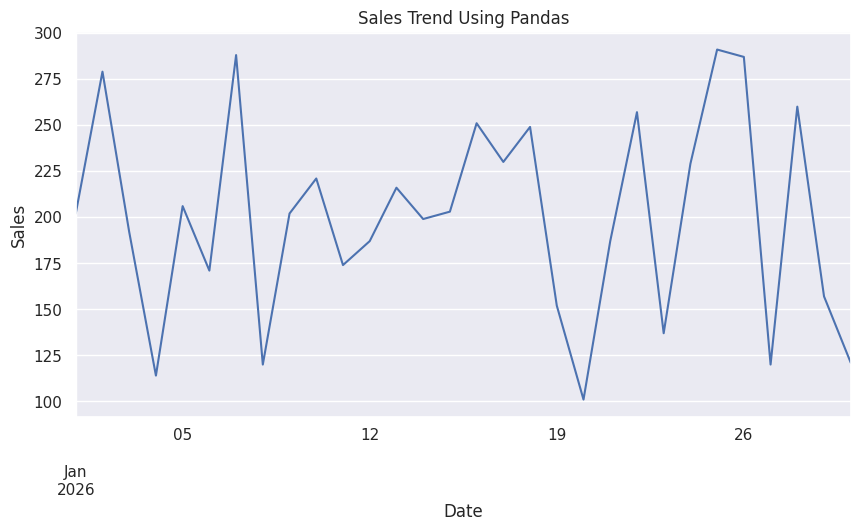

In [12]:
df.set_index("Date")["Sales"].plot(
    figsize=(10, 5),
    title="Sales Trend Using Pandas"
)

plt.ylabel("Sales")
plt.show()

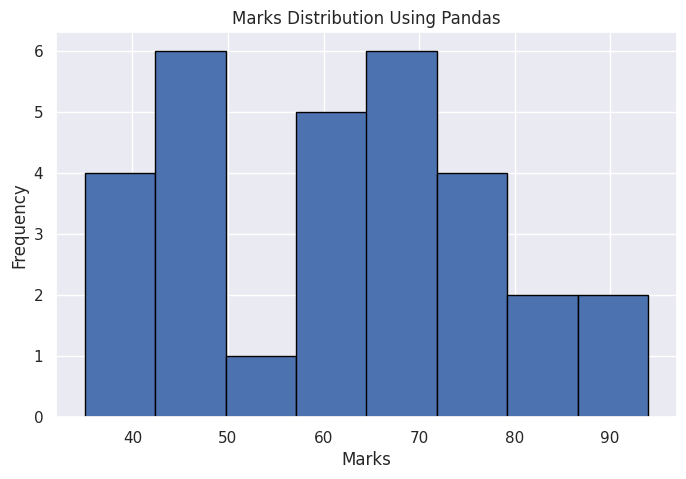

In [13]:
df["Marks"].plot(
    kind="hist",
    bins=8,
    figsize=(8, 5),
    title="Marks Distribution Using Pandas",
    edgecolor="black"
)
plt.xlabel("Marks")
plt.show()

## 15. Matplotlib vs Seaborn vs Pandas Plotting

| Feature | Matplotlib | Seaborn | Pandas Plotting |
|---|---|---|---|
| Main purpose | General visualization | Statistical visualization | Quick DataFrame visualization |
| Control | Very high | High | Moderate |
| Ease of use | Moderate | Easy | Very easy |
| Statistical plots | Possible | Strong | Basic |
| Works directly with DataFrames | Yes | Yes | Yes |
| Typical use | Customized charts | EDA/statistical charts | Quick exploration |

A practical workflow often uses all three.

## 16. Customizing Visualizations

Important components:

- Figure size
- Title
- X-axis label
- Y-axis label
- Legend
- Grid
- Tick rotation
- Limits
- Annotations

Good visualization should be readable and should not contain unnecessary decoration.

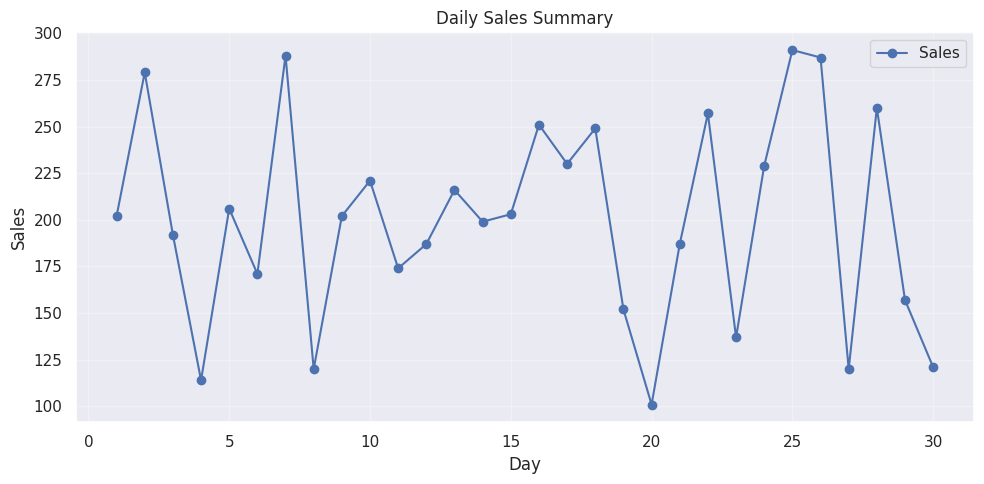

In [14]:
monthly = df.groupby(df["Date"].dt.day)["Sales"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o", label="Sales")
plt.title("Daily Sales Summary")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Visualizing Findings

A visualization is not the final result. The analyst must interpret it.

A useful interpretation should answer:

1. What does the chart show?
2. What pattern is visible?
3. Is there an unusual observation?
4. What comparison is important?
5. What conclusion is supported by the chart?

### Example

Instead of writing:

"Here is a scatter plot."

Write:

"The scatter plot shows how attendance varies with marks. The points indicate the observed relationship in this sample, although the chart alone does not establish causation."

## 18. Common Visualization Mistakes

### Mistake 1: Wrong chart type

Using a pie chart or line chart when a simple bar chart better communicates category comparisons.

### Mistake 2: Missing labels

A chart without axis labels or a meaningful title can be difficult to interpret.

### Mistake 3: Misleading axes

Changing axis limits can exaggerate or hide differences.

### Mistake 4: Too many variables

Putting too much information into one chart makes it difficult to understand.

### Mistake 5: Ignoring missing values

Missing observations can affect both the analysis and the visualization.

### Mistake 6: Treating correlation as causation

A relationship shown by a visualization does not automatically prove that one variable causes another.

### Mistake 7: Decorative charts

A chart should communicate information, not merely look attractive.

## 19. Complete Visualization Workflow

A typical data-science visualization workflow is:

**Collect data -> Inspect -> Clean -> Transform -> Analyze -> Visualize -> Interpret -> Communicate**

Example:

1. Load the dataset.
2. Check columns and data types.
3. Handle missing or invalid values.
4. Select relevant variables.
5. Summarize the data.
6. Choose an appropriate chart.
7. Create and customize the chart.
8. Interpret the result.
9. Communicate the finding.

  Department  Average_Marks  Average_Attendance  Total_Sales
0         CE      56.666667           79.000000         1632
1        CSE      63.250000           80.083333         2559
2        ECE      63.750000           83.000000          680
3         ME      65.400000           88.600000         1132


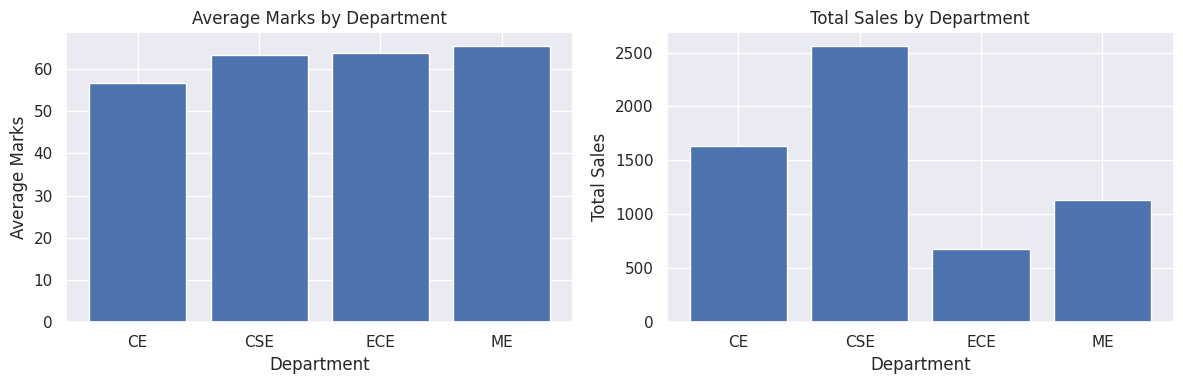

In [15]:
# Example workflow
analysis = df.groupby("Department").agg(
    Average_Marks=("Marks", "mean"),
    Average_Attendance=("Attendance", "mean"),
    Total_Sales=("Sales", "sum")
).reset_index()

print(analysis)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(analysis["Department"], analysis["Average_Marks"])
axes[0].set_title("Average Marks by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Average Marks")

axes[1].bar(analysis["Department"], analysis["Total_Sales"])
axes[1].set_title("Total Sales by Department")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

## 20. Exam Revision

### Data Visualization
Graphical representation of data to communicate patterns, trends, relationships, and findings.

### Matplotlib
A general-purpose Python visualization library providing detailed control over plots.

### Seaborn
A statistical visualization library built on Matplotlib that provides high-level plotting functions.

### Histogram
Used to visualize the distribution of a numerical variable.

### Scatter Plot
Used to visualize the relationship between two numerical variables.

### Bar Chart
Used to compare values across discrete categories.

### Line Plot
Used to show trends over an ordered variable, commonly time.

### Heatmap
Uses color/intensity to represent values in a matrix.

### Pair Plot
Displays pairwise relationships and distributions for multiple variables.

### Violin Plot
Shows the distribution of numerical data across categories.

### Regression Plot
Shows observations along with an estimated regression trend.

## 21. Important Exam Comparisons

### Bar Chart vs Histogram

| Bar Chart | Histogram |
|---|---|
| Categorical/discrete comparisons | Numerical distribution |
| Bars represent categories | Bars represent numerical bins |
| Categories are distinct | Bins represent ranges |

### Scatter Plot vs Line Plot

| Scatter Plot | Line Plot |
|---|---|
| Relationship between variables | Trend across an ordered sequence |
| Points are emphasized | Connected sequence is emphasized |
| Useful for correlation exploration | Useful for time/order-based trends |

### Matplotlib vs Seaborn

| Matplotlib | Seaborn |
|---|---|
| Lower-level plotting control | Higher-level statistical interface |
| Highly customizable | Convenient statistical plots |
| General-purpose | Strong for EDA/statistical visualization |

## 22. Very Short Answer Questions

1. What is data visualization?
2. Why is data visualization important?
3. What is Matplotlib?
4. What is Seaborn?
5. What is a histogram?
6. What is a scatter plot?
7. What is a bar chart?
8. What is a line plot?
9. What is a heatmap?
10. What is a pair plot?
11. What is a violin plot?
12. What is a regression plot?
13. What is correlation?
14. What is a subplot?
15. Why are axis labels important?

## 23. Short Answer Questions

1. Explain the importance of data visualization.
2. How do you choose an appropriate visualization?
3. Explain a line plot with an example.
4. Explain a bar chart with an example.
5. Explain a histogram.
6. Explain a scatter plot.
7. Explain subplots in Matplotlib.
8. Explain Seaborn and its advantages.
9. Explain pair plots.
10. Explain violin plots.
11. Explain heatmaps.
12. Explain regression plots.
13. Explain Pandas plotting.
14. Differentiate Matplotlib and Seaborn.
15. Explain common mistakes in data visualization.

## 24. Long Answer Questions

1. Explain data visualization and its importance in data science.
2. Explain different types of visualizations and their applications.
3. Explain Matplotlib with suitable examples.
4. Explain line, bar, scatter, and histogram plots.
5. Explain subplots and their applications.
6. Explain Seaborn and its major visualization functions.
7. Explain pair plots, violin plots, heatmaps, and regression plots.
8. Explain how Pandas can be used for quick visualization.
9. Explain a complete data visualization workflow.
10. Discuss common visualization mistakes and how to avoid them.

## 25. Viva Questions

1. What is the difference between Matplotlib and Seaborn?
2. When would you use a histogram?
3. When would you use a scatter plot?
4. Why is a line plot useful for time-series data?
5. What does `bins` mean in a histogram?
6. What is the purpose of `figsize`?
7. Why are axis labels important?
8. What does `plt.show()` do?
9. What is a subplot?
10. What does `sns.heatmap()` do?
11. What does `sns.pairplot()` do?
12. What is a violin plot?
13. What is a regression plot?
14. What is correlation?
15. Does correlation prove causation?
16. Why should charts have meaningful titles?
17. How can Pandas create charts?
18. Why can too many variables make a chart difficult to understand?
19. What is exploratory data analysis?
20. Why should visualization come after appropriate data preparation?

## 26. Practical Exercises

Try these without looking at the solutions.

### Exercise 1
Create a line plot showing monthly sales.

### Exercise 2
Create a bar chart comparing total sales by department.

### Exercise 3
Create a scatter plot showing attendance versus marks.

### Exercise 4
Create a histogram of marks with at least 8 bins.

### Exercise 5
Create a Seaborn violin plot of marks by department.

### Exercise 6
Create a correlation heatmap for all numerical variables.

### Exercise 7
Create a pair plot using Sales, Customers, Advertising, Marks, and Attendance.

### Exercise 8
Create a regression plot for Attendance and Marks.

### Exercise 9
Create two subplots showing sales and customer trends.

### Exercise 10
Create a Pandas bar plot showing average marks by department.

## 27. Practice Solutions

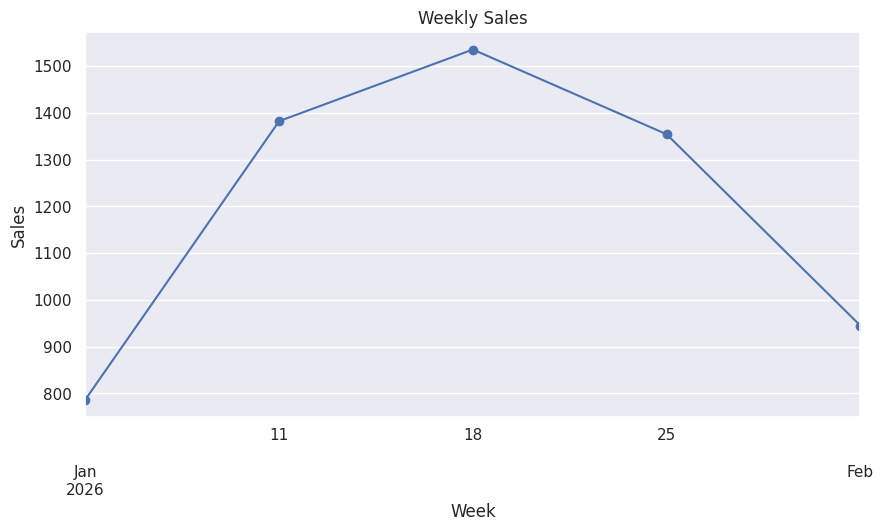

In [16]:
# Exercise 1
monthly_sales = df.groupby(df["Date"].dt.to_period("W"))["Sales"].sum()

monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Weekly Sales"
)
plt.xlabel("Week")
plt.ylabel("Sales")
plt.show()

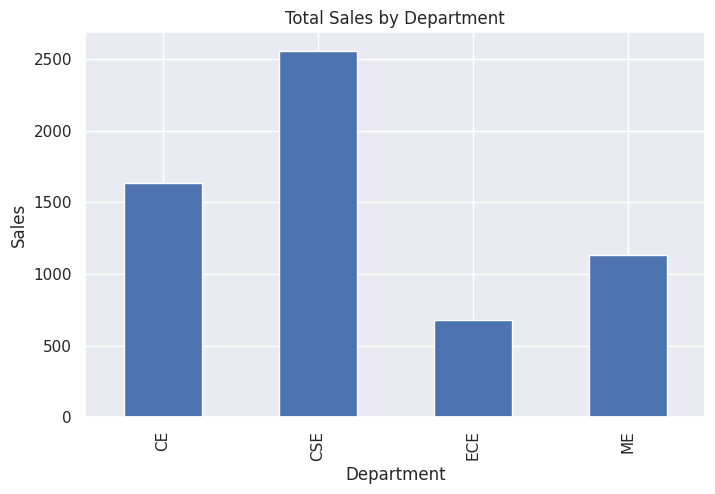

In [17]:
# Exercise 2
sales_by_department = df.groupby("Department")["Sales"].sum()

sales_by_department.plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Department"
)
plt.xlabel("Department")
plt.ylabel("Sales")
plt.show()

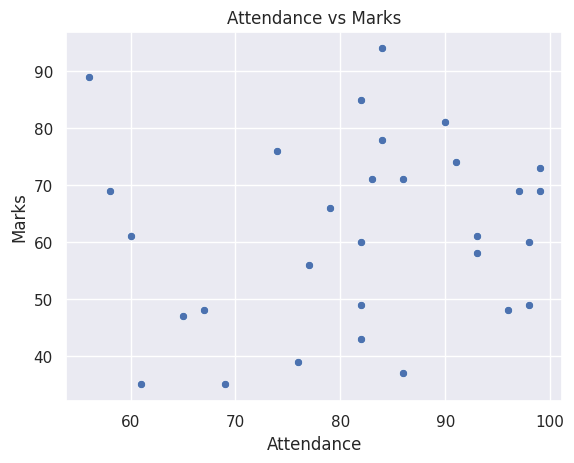

In [18]:
# Exercise 3
sns.scatterplot(data=df, x="Attendance", y="Marks")
plt.title("Attendance vs Marks")
plt.show()

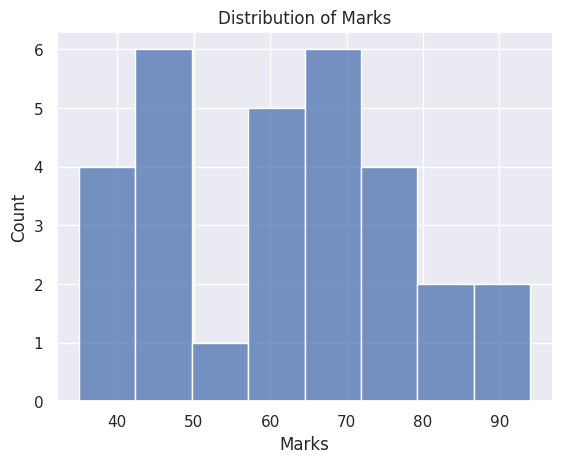

In [19]:
# Exercise 4
sns.histplot(data=df, x="Marks", bins=8)
plt.title("Distribution of Marks")
plt.show()

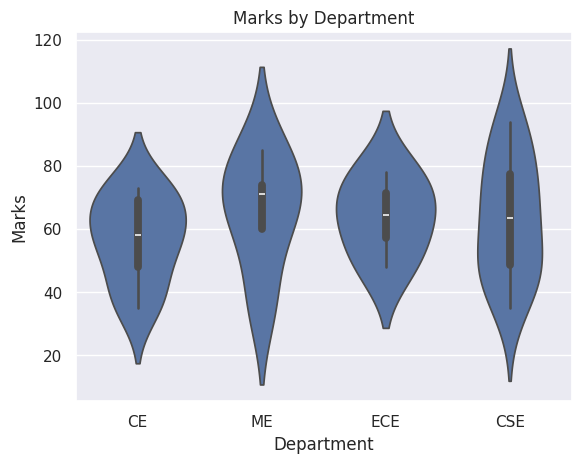

In [20]:
# Exercise 5
sns.violinplot(data=df, x="Department", y="Marks")
plt.title("Marks by Department")
plt.show()

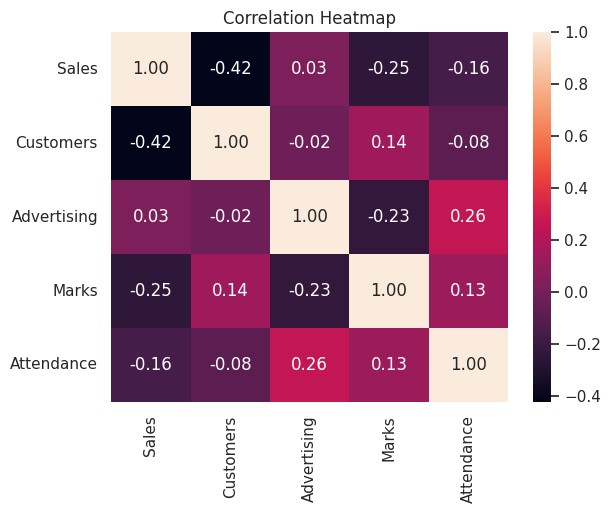

In [21]:
# Exercise 6
corr = df[["Sales", "Customers", "Advertising", "Marks", "Attendance"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

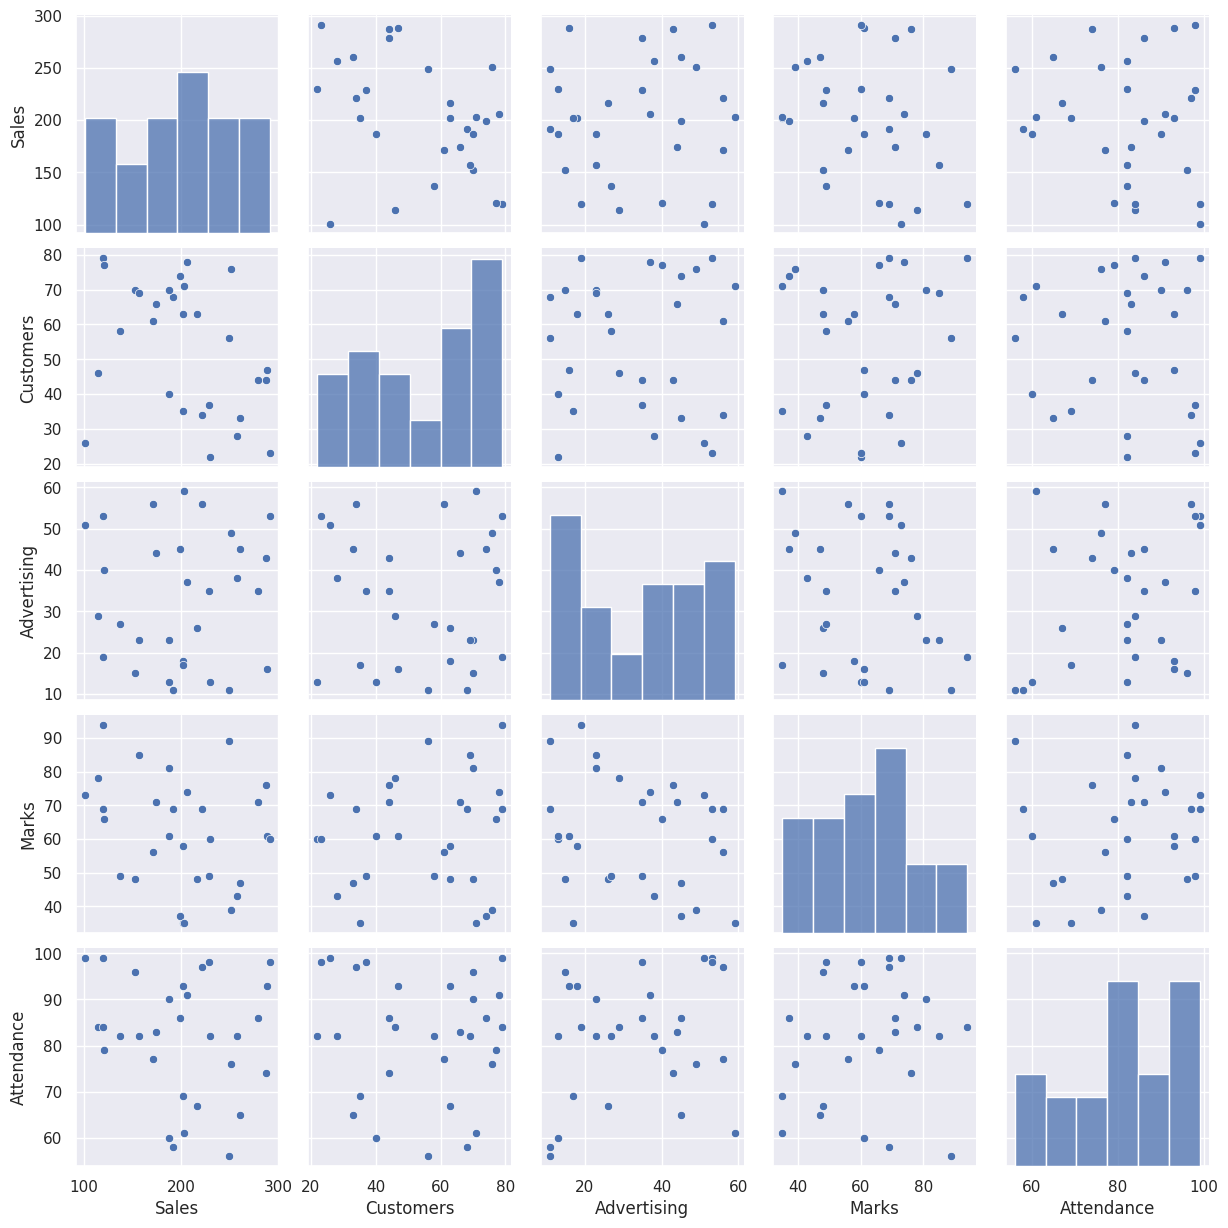

In [22]:
# Exercise 7
sns.pairplot(df[["Sales", "Customers", "Advertising", "Marks", "Attendance"]])
plt.show()

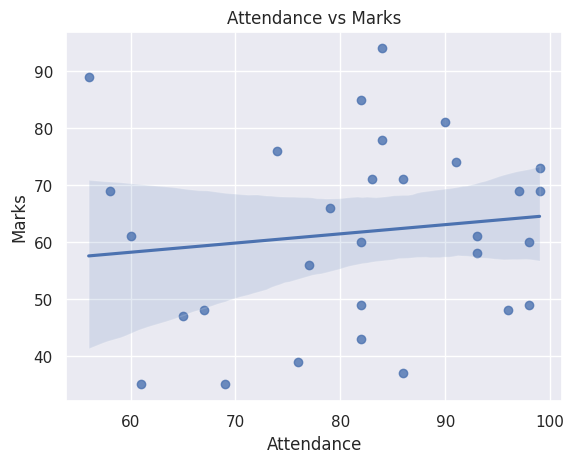

In [23]:
# Exercise 8
sns.regplot(data=df, x="Attendance", y="Marks")
plt.title("Attendance vs Marks")
plt.show()

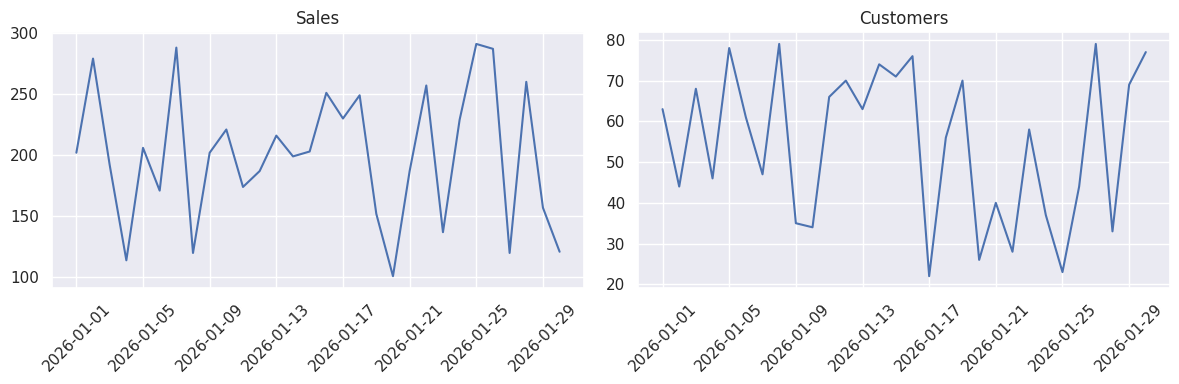

In [24]:
# Exercise 9
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["Date"], df["Sales"])
axes[0].set_title("Sales")

axes[1].plot(df["Date"], df["Customers"])
axes[1].set_title("Customers")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

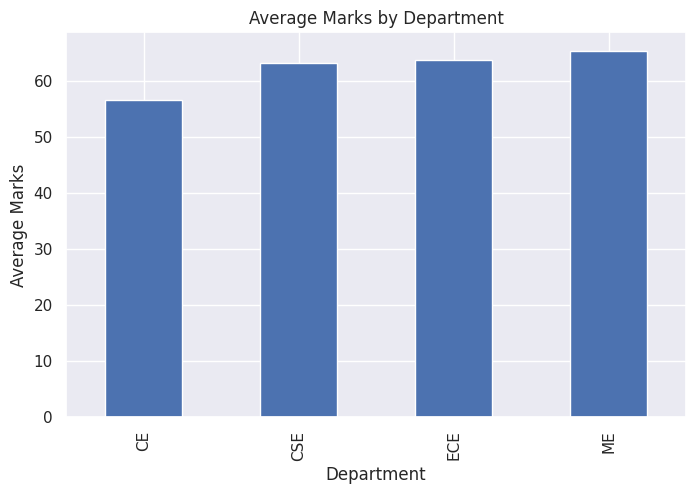

In [25]:
# Exercise 10
avg_marks = df.groupby("Department")["Marks"].mean()

avg_marks.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Marks by Department"
)
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

# Final Data Visualization Cheat Sheet

## Matplotlib

```python
plt.plot(x, y)
plt.bar(x, y)
plt.scatter(x, y)
plt.hist(data, bins=10)
plt.subplots()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Title")
plt.legend()
plt.grid()
plt.show()
```

## Seaborn

```python
sns.lineplot(data=df, x="Date", y="Sales")
sns.barplot(data=df, x="Department", y="Marks")
sns.scatterplot(data=df, x="Attendance", y="Marks")
sns.histplot(data=df, x="Marks")
sns.violinplot(data=df, x="Department", y="Marks")
sns.heatmap(df.corr(numeric_only=True), annot=True)
sns.pairplot(df)
sns.regplot(data=df, x="Attendance", y="Marks")
```

## Pandas

```python
df["Sales"].plot()
df["Marks"].plot(kind="hist")
df.groupby("Department")["Sales"].sum().plot(kind="bar")
```

## Chart Selection

- Trend -> Line plot
- Category comparison -> Bar chart
- Two numerical variables -> Scatter plot
- Numerical distribution -> Histogram
- Category-wise distribution -> Violin plot
- Many numerical relationships -> Pair plot
- Correlation matrix -> Heatmap
- Linear relationship -> Regression plot
- Multiple related views -> Subplots